In [ ]:
a=[1,2,3,{6,7,8}] #set, tuple haven't copy shallow,deep

In [53]:
a={1,3,4}

In [54]:
import copy


In [55]:
b=copy.deepcopy(a)

In [56]:
a[0]=66


TypeError: 'set' object does not support item assignment

In [66]:
a=[1,2,3,[8,9,0]] # list string copy inner outer, shallow deep

In [67]:
b=a.copy()

In [68]:
a[3][0]=89

In [69]:
a

[1, 2, 3, [89, 9, 0]]

In [65]:
b

[1, 2, 3]

In [1]:
import numpy as np
d=np.array([2,3,4,6,7,8,9,12,13,16,17,23,25,37,34,37,301])

In [2]:
d

array([  2,   3,   4,   6,   7,   8,   9,  12,  13,  16,  17,  23,  25,
        37,  34,  37, 301])

In [3]:
q1=np.percentile(d,25)

In [4]:
q1

np.float64(7.0)

In [5]:
q3=np.percentile(d,75)

In [6]:
q3

np.float64(25.0)

In [7]:
IQR=q3-q1

In [8]:
IQR

np.float64(18.0)

In [9]:
U=q3+1.5*IQR
U



np.float64(52.0)

In [10]:
L=q1-1.5*IQR
L

np.float64(-20.0)

In [11]:
l=[]
for i in d:
    if i>=L and i<=U:
        l.append(i)
d2=np.array(l)

In [12]:
print(d)
print(d2)

[  2   3   4   6   7   8   9  12  13  16  17  23  25  37  34  37 301]
[ 2  3  4  6  7  8  9 12 13 16 17 23 25 37 34 37]


In [13]:
import seaborn as sns


<Axes: >

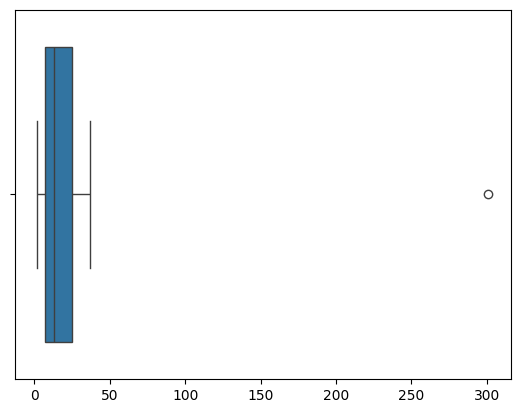

In [14]:
sns.boxplot(x=d)

<Axes: >

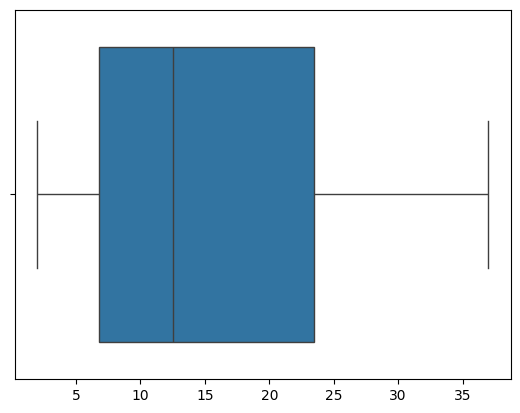

In [15]:
sns.boxplot(x=d2)

<h3>Z-test</h3>

In [18]:
import numpy as np 
from scipy.stats import norm


In [23]:
# sample size must be 30>=
sample=[172,174,168,169,171,173,175,170,169,172]


In [24]:
mew=170
std=3
meann=np.mean(sample)
element=len(sample)


In [25]:
z=(meann-mew)/(std/np.sqrt(element))

In [26]:
z

np.float64(1.3703203194063098)

In [28]:
p_val=2*(1-norm.cdf(abs(z)))

In [33]:
p_val

np.float64(0.17058693287143756)

In [34]:
alpha=0.05

In [35]:
if p_val>alpha:
    print("there is difference")
else:
    print("there is no difference")


there is difference


<h3>T-test</h3>

<img src='t-table.png' width='500'>

In [37]:
import numpy as np 
from scipy import stats


In [38]:
sample=[172,174,168,169,171,173,175,170,169,172]

In [41]:
mean=np.mean(sample)
n=len(sample)
# degree of freedom=n-1
std=np.std(sample,ddof=1)
mew=170

In [45]:
t_test=(mean-mew)/(std/np.sqrt(n))

In [46]:
t_test

np.float64(1.7782469350914734)

In [50]:
p_val=2*(1-stats.t.cdf(abs(t_test),df=n-1))
alpha=0.05 #2.262

In [52]:
p_val

np.float64(0.10907771593031335)

In [51]:
if p_val>alpha:
    print("there is difference")
else:
    print("there is no difference")


there is difference


<h3>Two Samples:T-test</h3>

In [54]:
import numpy as np 
from scipy import stats


In [63]:
g1=[85,88,90,92,87,85,89,91,86,88]
g2=[82,84,80,83,81,79,78,85,84,83]

In [64]:
t_stat,p_val=stats.ttest_ind(g1,g2,equal_var=False)

In [65]:
alpha=0.05

In [66]:
t_stat

np.float64(5.829604009507161)

In [67]:
p_val

np.float64(1.610475598965881e-05)

In [59]:
if p_val>alpha:
    print("there is difference")
else:
    print("there is no difference")


there is no difference


<h3>Chi-Squared Test</h3>

<img src='chi-square-distribution-table.png' width=600>

In [70]:
import pandas as pd 
import numpy as np 
from scipy.stats import chi2_contingency
import seaborn as sns

In [71]:
df= sns.load_dataset('titanic')

In [72]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [73]:
ct_table=pd.crosstab(df['sex'],df['survived'])

In [74]:
ct_table

survived,0,1
sex,,
female,81,233
male,468,109


In [75]:
chi2, p_val, dof, expexted=chi2_contingency(ct_table)

In [76]:
expexted

array([[193.47474747, 120.52525253],
       [355.52525253, 221.47474747]])

In [77]:
p_val

np.float64(1.1973570627755645e-58)

In [78]:
dof

1

In [79]:
alpha=0.05 #3.841

In [80]:
if p_val>alpha:
    print('there is difference')
else:
    print('there is no difference')


there is na difference


<h3>ANNOVA(f-test)</h3>

In [12]:
import seaborn as sns 
import pandas as pd 
from scipy.stats import f_oneway

In [13]:
df=sns.load_dataset('titanic')

In [14]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


drop column dekh nhi sakate if you want to show them then convert into 0
df['age'].fillna(0,inplace=True)
df


In [4]:
df=df[['age','pclass']].dropna()

In [20]:
df[0:100]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,3,male,0.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
96,0,1,male,71.0,0,0,34.6542,C,First,man,True,A,Cherbourg,no,True
97,1,1,male,23.0,0,1,63.3583,C,First,man,True,D,Cherbourg,yes,False
98,1,2,female,34.0,0,1,23.0000,S,Second,woman,False,NaN,Southampton,yes,False


In [6]:
df['pclass'].unique()

array([3, 1, 2])

In [7]:
c1=df[df['pclass']==1]['age']
c2=df[df['pclass']==2]['age']
c3=df[df['pclass']==3]['age']

In [8]:
c1

1      38.0
3      35.0
6      54.0
11     58.0
23     28.0
       ... 
871    47.0
872    33.0
879    56.0
887    19.0
889    26.0
Name: age, Length: 186, dtype: float64

In [9]:
f_stats,p_val=f_oneway(c1,c2,c3)

In [10]:
f_stats

np.float64(57.44348434067624)

In [22]:
p_val

np.float64(7.487984171959212e-24)

In [23]:
alpha=0.05

In [24]:
if p_val>alpha:
    print('there is difference')
else:
    print('there is no difference')

there is no difference
